# Φάση Ε: Model Evaluation & Σύγκριση

**Υπεύθυνος:** ML Engineer

**Μετρικές:**
- Accuracy
- Precision / Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

**Οπτικοποιήσεις:**
1. Confusion Matrix (heatmap)
2. ROC Curve
3. Συγκριτικά bar charts
4. Πίνακας σύγκρισης

Εκκίνηση SparkSession...


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/03 18:24:58 WARN Utils: Your hostname, cachyos-x8664, resolves to a loopback address: 127.0.1.1; using 192.168.1.5 instead (on interface enp4s0)
26/06/03 18:24:58 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/03 18:24:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/03 18:24:59 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/06/03 18:24:59 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


Φόρτωση προβλέψεων...

Αξιολόγηση: Random Forest
Βέλτιστο Threshold: 0.624
              precision    recall  f1-score   support

         0.0       0.98      0.82      0.89       945
         1.0       0.14      0.67      0.23        42

    accuracy                           0.81       987
   macro avg       0.56      0.74      0.56       987
weighted avg       0.95      0.81      0.87       987


Αξιολόγηση: Support Vector Machine (SVM)
              precision    recall  f1-score   support

         0.0       0.99      0.72      0.83       945
         1.0       0.11      0.79      0.20        42

    accuracy                           0.72       987
   macro avg       0.55      0.75      0.51       987
weighted avg       0.95      0.72      0.81       987


Αξιολόγηση: Naive Bayes
Βέλτιστο Threshold: 0.781
              precision    recall  f1-score   support

         0.0       0.98      0.75      0.85       945
         1.0       0.10      0.60      0.17        42

    accuracy  

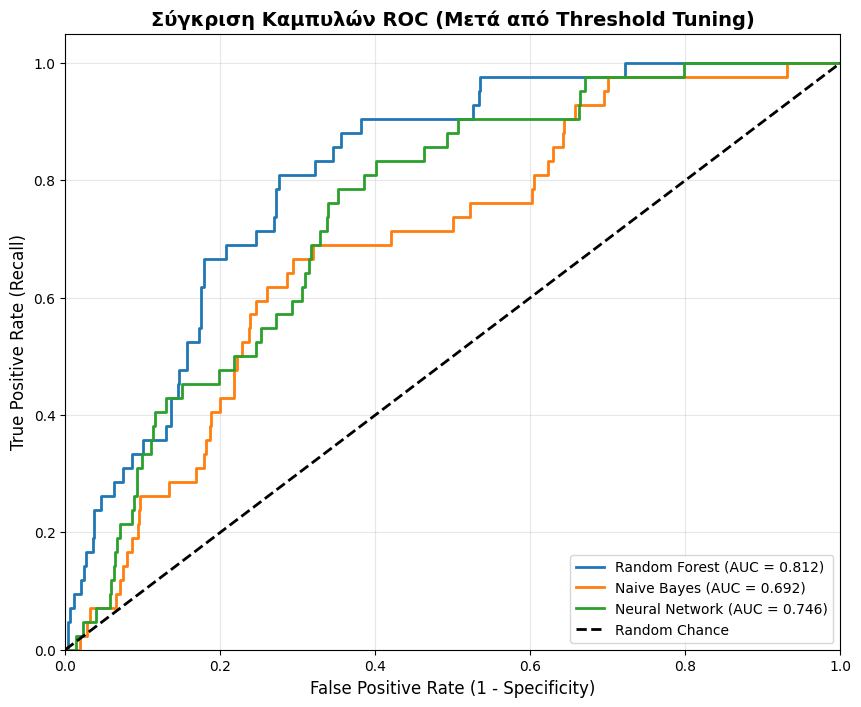


--- Αξιολόγηση K-Means ---


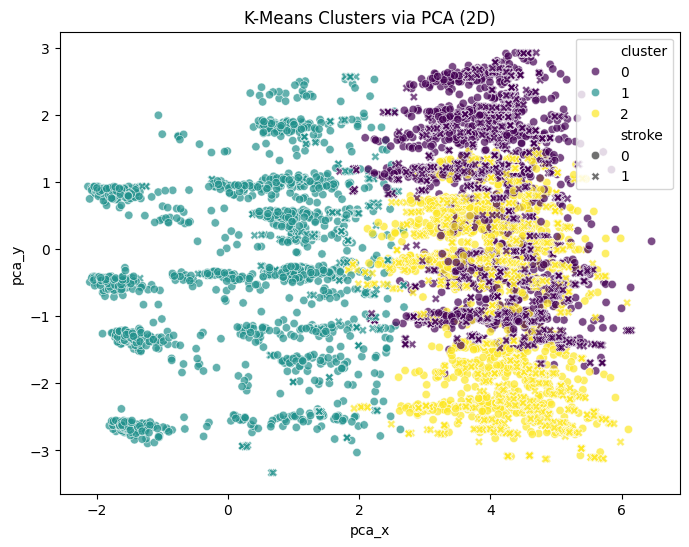

In [1]:
# =====================================================================
# Φάση Ε: Model Evaluation & Σύγκριση (ΠΛΗΡΗΣ ΑΞΙΟΛΟΓΗΣΗ)
# =====================================================================

from pyspark.sql import SparkSession
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc, 
                             precision_recall_curve, silhouette_score)

print("Εκκίνηση SparkSession...")
spark = SparkSession.builder.appName("Evaluation_Metrics").master("local[*]").getOrCreate()

# 1. Φόρτωση Προβλέψεων σε Pandas DataFrames
print("Φόρτωση προβλέψεων...")
df_rf = spark.read.parquet("../data/rf_predictions.parquet").toPandas()
df_svm = spark.read.parquet("../data/svm_predictions.parquet").toPandas()
df_nb = spark.read.parquet("../data/nb_predictions.parquet").toPandas()
df_mlp = spark.read.parquet("../data/mlp_predictions.parquet").toPandas()
df_kmeans = spark.read.parquet("../data/preds_kmeans.parquet").toPandas()

# 2. Συνάρτηση Αξιολόγησης (Με Threshold Tuning για Imbalanced Δεδομένα)
def evaluate_model(df, model_name, has_probability=True):
    print(f"\n{'='*40}")
    print(f"Αξιολόγηση: {model_name}")
    print(f"{'='*40}")
    
    if has_probability:
        # Εξαγωγή prob_stroke από το PySpark DenseVector
        df['prob_stroke'] = df['probability'].apply(lambda x: x[1])
        
        # Υπολογισμός βέλτιστου Threshold βάσει F1-Score
        precisions, recalls, thresholds = precision_recall_curve(df['stroke'], df['prob_stroke'])
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
        best_threshold = thresholds[np.argmax(f1_scores)]
        
        # Εφαρμογή νέου Threshold
        df['tuned_prediction'] = (df['prob_stroke'] >= best_threshold).astype(int)
        
        print(f"Βέλτιστο Threshold: {best_threshold:.3f}")
        print(classification_report(df['stroke'], df['tuned_prediction']))
        
        # Υπολογισμός ROC-AUC
        fpr, tpr, _ = roc_curve(df['stroke'], df['prob_stroke'])
        roc_auc = auc(fpr, tpr)
        
        # Confusion Matrix
        cm = confusion_matrix(df['stroke'], df['tuned_prediction'])
    else:
        # Για SVM (LinearSVC) που δεν έβγαλε probabilities
        print(classification_report(df['stroke'], df['prediction']))
        fpr, tpr, roc_auc = None, None, None
        cm = confusion_matrix(df['stroke'], df['prediction'])
    
    return fpr, tpr, roc_auc, cm

# 3. Αξιολόγηση Μοντέλων
fpr_rf, tpr_rf, auc_rf, cm_rf = evaluate_model(df_rf, "Random Forest")
_, _, _, cm_svm = evaluate_model(df_svm, "Support Vector Machine (SVM)", has_probability=False)
fpr_nb, tpr_nb, auc_nb, cm_nb = evaluate_model(df_nb, "Naive Bayes")
fpr_mlp, tpr_mlp, auc_mlp, cm_mlp = evaluate_model(df_mlp, "Neural Networks (MLP)")

# 4. Σύγκριση Καμπυλών ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', linewidth=2)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.3f})', linewidth=2)
plt.plot(fpr_mlp, tpr_mlp, label=f'Neural Network (AUC = {auc_mlp:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Σύγκριση Καμπυλών ROC (Μετά από Threshold Tuning)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 5. K-MEANS Evaluation (Ανάλυση Κύριων Συνιστωσών / PCA)
print("\n--- Αξιολόγηση K-Means ---")
df_kmeans['pca_x'] = df_kmeans['pca_features'].apply(lambda x: x[0])
df_kmeans['pca_y'] = df_kmeans['pca_features'].apply(lambda x: x[1])

plt.figure(figsize=(8, 6))
sns.scatterplot(x='pca_x', y='pca_y', hue='cluster', style='stroke', data=df_kmeans, palette='viridis', alpha=0.7)
plt.title('K-Means Clusters via PCA (2D)')
plt.show()